In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import re

Settings

In [2]:
results_path = Path(
    '../results/'
)

In [3]:
df_metrics = pd.read_excel(
    Path(
        results_path, 'metrics_modelling4_7-dim_reduction.xlsx'
    ),
)

display(df_metrics.head())
df_metrics.info()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_class_0_mean,cv_train_recall_class_0_median,cv_train_recall_class_0_std,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std
0,df_dimless,splashing,Logit_splashing_smote_1-dim_vae,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.520000,0.750000,0.375000,0.500000,0.590278,0.519231,...,0.775268,0.778761,0.015334,0.388207,0.380488,0.030478,"0.7276710554716167, 0.6706033376123234, 0.7114...",0.708321,0.722227,0.034057
1,df_dimless,splashing,CatBoostClassifier_splashing_smote_1-dim_vae,"{'estimator': 'CatBoostClassifier', 'estimator...",0.693333,0.790698,0.708333,0.747253,0.766590,0.678711,...,0.802981,0.814159,0.049250,0.862464,0.843902,0.040983,"0.923267860997194, 0.9397732135216089, 0.90235...",0.919807,0.923268,0.013274
2,df_dimless,no_fragmentation,Logit_no_fragmentation_smote_1-dim_vae,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.693333,0.448276,0.650000,0.530612,0.711818,0.651445,...,0.487790,0.427350,0.147215,0.629452,0.717647,0.175857,"0.5747354497354497, 0.5849170437405732, 0.6214...",0.575583,0.584917,0.068254
3,df_dimless,no_fragmentation,CatBoostClassifier_no_fragmentation_smote_1-di...,"{'estimator': 'CatBoostClassifier', 'estimator...",0.813333,0.593750,0.950000,0.730769,0.887273,0.793956,...,0.813797,0.807692,0.026625,0.850300,0.847059,0.050007,"0.9506512006512006, 0.8983408748114631, 0.8984...",0.914181,0.898441,0.028069
4,df_dimless,splashing,Logit_splashing_smote_2-dim_vae,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.560000,0.758621,0.458333,0.571429,0.695216,0.559687,...,0.748642,0.734513,0.075143,0.572961,0.592233,0.040044,"0.6321821713792358, 0.7675224646983311, 0.7252...",0.705291,0.722270,0.046443


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Columns: 112 entries, dataset to cv_train_roc_auc_std
dtypes: float64(86), object(26)
memory usage: 84.1+ KB


In [4]:
df_main_metrics = pd.read_excel(
    Path(
        results_path, 'metrics_modelling4.xlsx'
    ),
)

display(df_main_metrics.head())
df_main_metrics.info()

,dataset,target,model,params,holdout_test_accuracy,holdout_test_precision,holdout_test_recall,holdout_test_f1,holdout_test_roc_auc,holdout_test_f1_macro,...,cv_train_recall_class_0_mean,cv_train_recall_class_0_median,cv_train_recall_class_0_std,cv_train_recall_mean,cv_train_recall_median,cv_train_recall_std,cv_train_roc_auc,cv_train_roc_auc_mean,cv_train_roc_auc_median,cv_train_roc_auc_std
0,df_dimless,splashing,Logit_splashing_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.800000,0.823529,0.875000,0.848485,0.874228,0.777184,...,0.784073,0.778761,0.017802,0.845821,0.844660,0.010156,"0.8959421541118067, 0.9114676936243047, 0.9020...",0.905980,0.907788,0.006070
1,df_dimless,no_fragmentation,Logit_no_fragmentation_default,"{'estimator': 'StatsModelsEstimator', 'estimat...",0.906667,0.809524,0.850000,0.829268,0.951818,0.882524,...,0.916361,0.914530,0.012056,0.760984,0.752941,0.021087,"0.9395604395604396, 0.9486676721970839, 0.9361...",0.940673,0.941277,0.005873
2,df_dimless,splashing,LogisticRegression_splashing_default,"{'estimator': 'LogisticRegression', 'estimator...",0.800000,0.823529,0.875000,0.848485,0.879630,0.777184,...,0.803036,0.796460,0.021463,0.838192,0.834951,0.009285,"0.8971077055903303, 0.912665810868635, 0.90327...",0.907306,0.909206,0.006459
3,df_dimless,no_fragmentation,LogisticRegression_no_fragmentation_default,"{'estimator': 'LogisticRegression', 'estimator...",0.826667,0.629630,0.850000,0.723404,0.946364,0.798595,...,0.843712,0.846154,0.010179,0.878792,0.870588,0.014996,"0.9391534391534391, 0.949270990447461, 0.93559...",0.940457,0.941679,0.005749
4,df_dimless,splashing,KNeighborsClassifier_splashing_default,"{'estimator': 'KNeighborsClassifier', 'estimat...",0.853333,0.862745,0.916667,0.888889,0.880787,0.836601,...,0.845942,0.849558,0.017741,0.916667,0.917476,0.010215,"0.9670192100151089, 0.9732563115104835, 0.9687...",0.968172,0.967738,0.002594


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Columns: 112 entries, dataset to cv_train_roc_auc_std
dtypes: float64(86), object(26)
memory usage: 215.4+ KB


In [5]:

for df in (df_metrics, df_main_metrics):
    df['model_class'] = df['model'].apply(
        lambda x: x.split('_')[0]
    )

df_metrics['dim_reduction_method'] = df_metrics['model'].apply(
    lambda x: x.split('_')[-1]
)

df_metrics['reduced_dimension'] = df_metrics['model'].apply(
    lambda x: int(x.split('_')[-2].replace('-dim', ''))
)

df_main_metrics['model_group'] = df_main_metrics['model'].apply(
    lambda x: x.split('_')[-1]
)

df_main_metrics['model_group'] = df_main_metrics['model_group'].apply(
    lambda x: 'default' if 'default' in x else 'opt'
)

def define_SMOTE(model):
    if 'smotenc' in model:
        return 'SMOTENC'
    elif 'smote' in model:
        return 'SMOTE'
    else:
        return 'no'
df_main_metrics['SMOTE'] = df_main_metrics['model'].apply(
    define_SMOTE
)

def define_SMOTE_opt(model):
    if 'smote' in model:
        if re.search(r'opt-[a-z-]*smote', model):
            if re.search(r'optuna-opt[a-z-]*smote', model):
                return 'optuna'
            else:
                return 'grid'
        else:
            return 'no'
    else:
        return None
df_main_metrics['SMOTE_opt'] = df_main_metrics['model'].apply(
    define_SMOTE_opt
)


cv_metrics = [
    'cv_test_f1_macro',
]

for df in (df_metrics, df_main_metrics):
    for metric in cv_metrics:
        df[metric] = df[metric].apply(
            lambda x: list(map(float, x.split(', ')))
        )


In [6]:
target = 'splashing'
model_class = 'Logit'
model_group = 'default'
SMOTE = 'SMOTE'
SMOTE_opt = 'no'

baseline_df = df_main_metrics[
    (df_main_metrics['target'] == target)
    & (df_main_metrics['model_class'] == model_class)
    & (df_main_metrics['model_group'] == model_group)
    & (df_main_metrics['SMOTE'] == SMOTE)
    & (df_main_metrics['SMOTE_opt'] == SMOTE_opt)
]

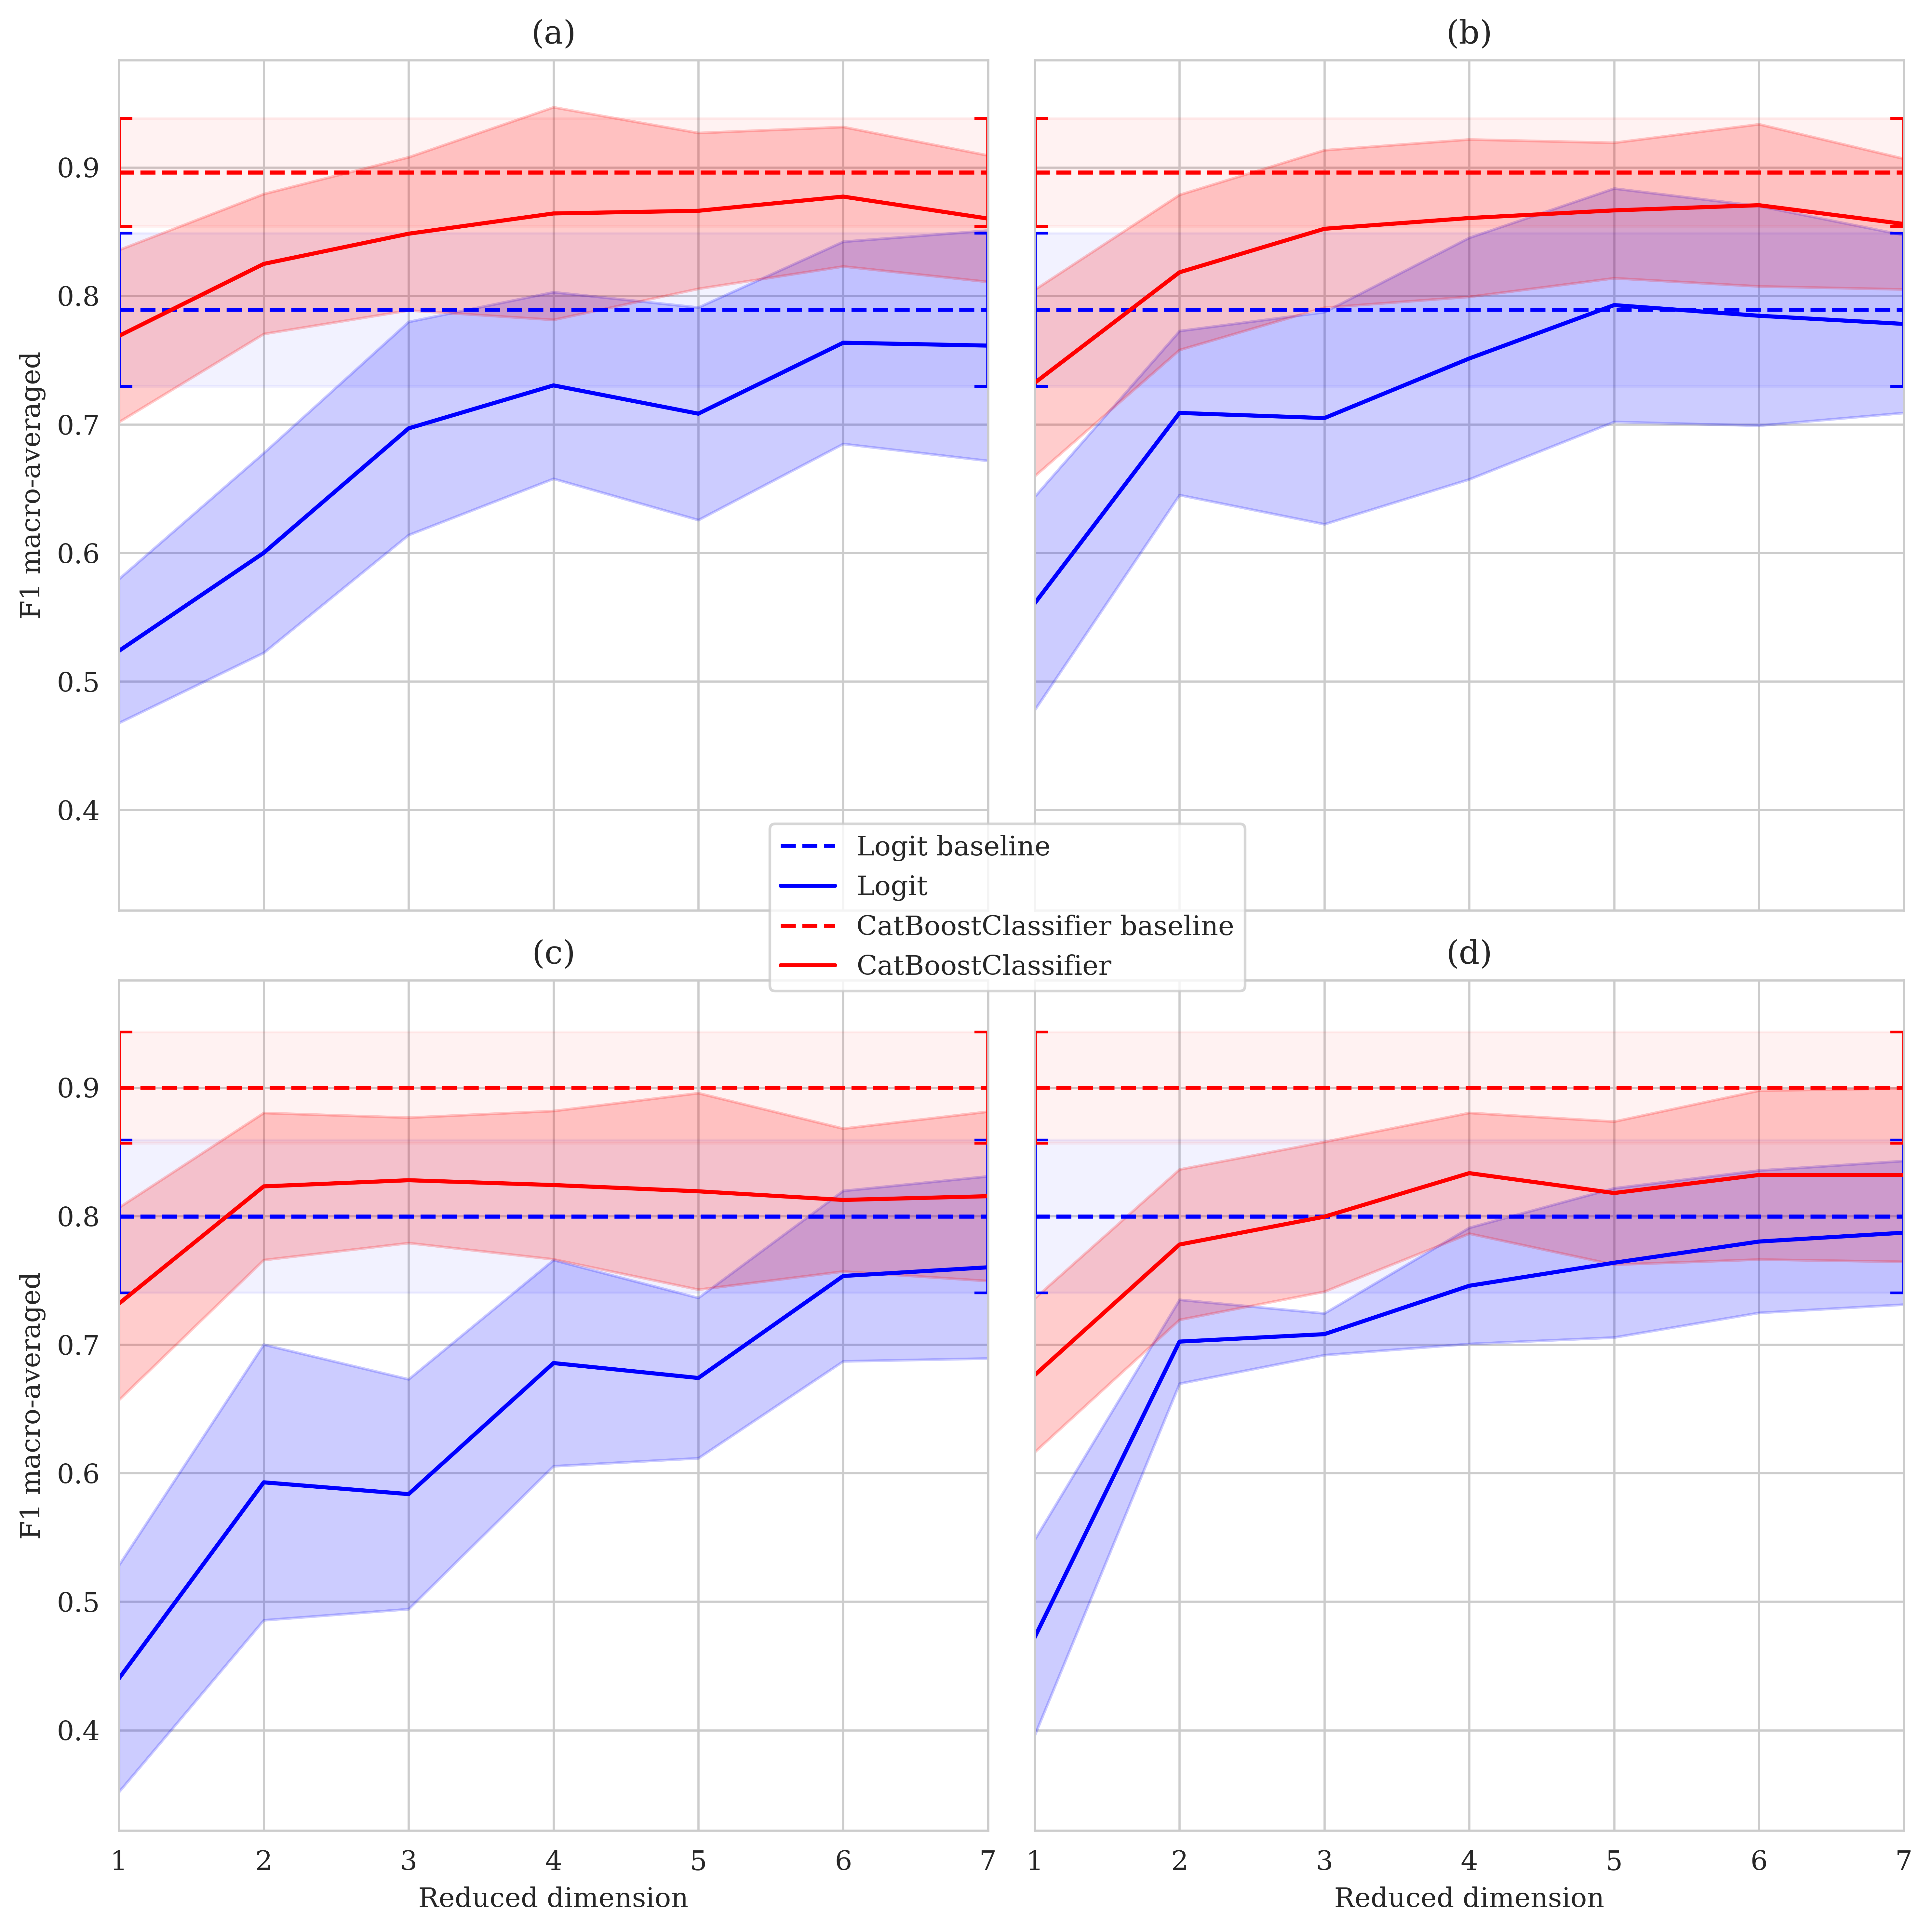

In [7]:
sns.set_style('whitegrid', {'font.family':'serif', 'font.serif':'Times New Roman'})

metric = 'cv_test_f1_macro'
model_group = 'default'
SMOTE_opt = 'no'
smote_dict = {
    'splashing': 'SMOTE',
    'no_fragmentation': 'SMOTENC',
}
dim_reduction_methods = ('vae', 'pca')

colors = ['blue', 'red']

fig, axes = plt.subplots(
    2, 2, figsize=(10,10), dpi=600, sharex=True, sharey=True,
)

titles = 'abcd'
# Store lines for common legend
legend_lines = []
legend_labels = []

for i, target in enumerate(['splashing', 'no_fragmentation']):
    for j, dim_reduction_method in enumerate(dim_reduction_methods):
        for k, model_class in enumerate(['Logit', 'CatBoostClassifier']):
            
            df_plot = df_metrics[
                (df_metrics['target'] == target)
                & (df_metrics['model_class'] == model_class)
                & (df_metrics['dim_reduction_method'] == dim_reduction_method)
            ]
            
            df_plot = (
                df_plot
                .explode(metric)
                .reset_index(drop=True)
            )
            
            SMOTE = smote_dict[target]
            baseline_df = df_main_metrics[
                (df_main_metrics['target'] == target)
                & (df_main_metrics['model_class'] == model_class)
                & (df_main_metrics['model_group'] == model_group)
                & (df_main_metrics['SMOTE'] == SMOTE)
                & (df_main_metrics['SMOTE_opt'] == SMOTE_opt)
            ]
            
            metrics = baseline_df[metric].values[0]
            
            mean = np.mean(metrics)
            std = np.std(metrics)
            
            # Add baseline line
            line = axes[i, j].axhline(
                y=mean,
                color=colors[k],
                linestyle='--',
                label=f'{model_class} baseline',
            )
            
            # Add error bars at the edges
            axes[i, j].errorbar(
                x=[1, 7],  # edge points on x
                y=[mean, mean],  # y values
                yerr=[std, std],  # errors
                color=colors[k],
                fmt='none',  # only errors, no markers
                capsize=5,  # size of cross lines
            )
            
            axes[i, j].fill_between(
                x=[1, df_plot['reduced_dimension'].max()],
                y1=mean - std,
                y2=mean + std,
                color=colors[k],
                alpha=0.05,
            )
            
            # Add line with points
            line_points = sns.lineplot(
                data=df_plot,
                x='reduced_dimension',
                y=metric,
                ax=axes[i, j],
                label=model_class,
                errorbar='sd',
                color=colors[k],
                legend=False,  # Disable individual legends
            )
            
            # Store lines and labels for common legend only once
            if i == 0 and j == 0:
                legend_lines.extend([line, line_points.lines[-1]])
                legend_labels.extend([f'{model_class} baseline', model_class])
        
        axes[i,j].set_title(f'({titles[i*2+j]})')
        axes[i,j].xaxis.set_major_locator(plt.MultipleLocator(1))
        axes[i,j].set_xlim(1, 7)
        axes[i,j].set_ylabel('F1 macro-averaged')
        axes[i,j].set_xlabel('Reduced dimension')

# Add common legend
fig.legend(
    legend_lines,
    legend_labels,
    loc='center right',  # Place legend on right center
    bbox_to_anchor=(0.65, 0.53),  # Legend position
)

# Adjust margins for legend placement
plt.tight_layout()
# plt.subplots_adjust(right=0.85)  # Leave space for legend on right

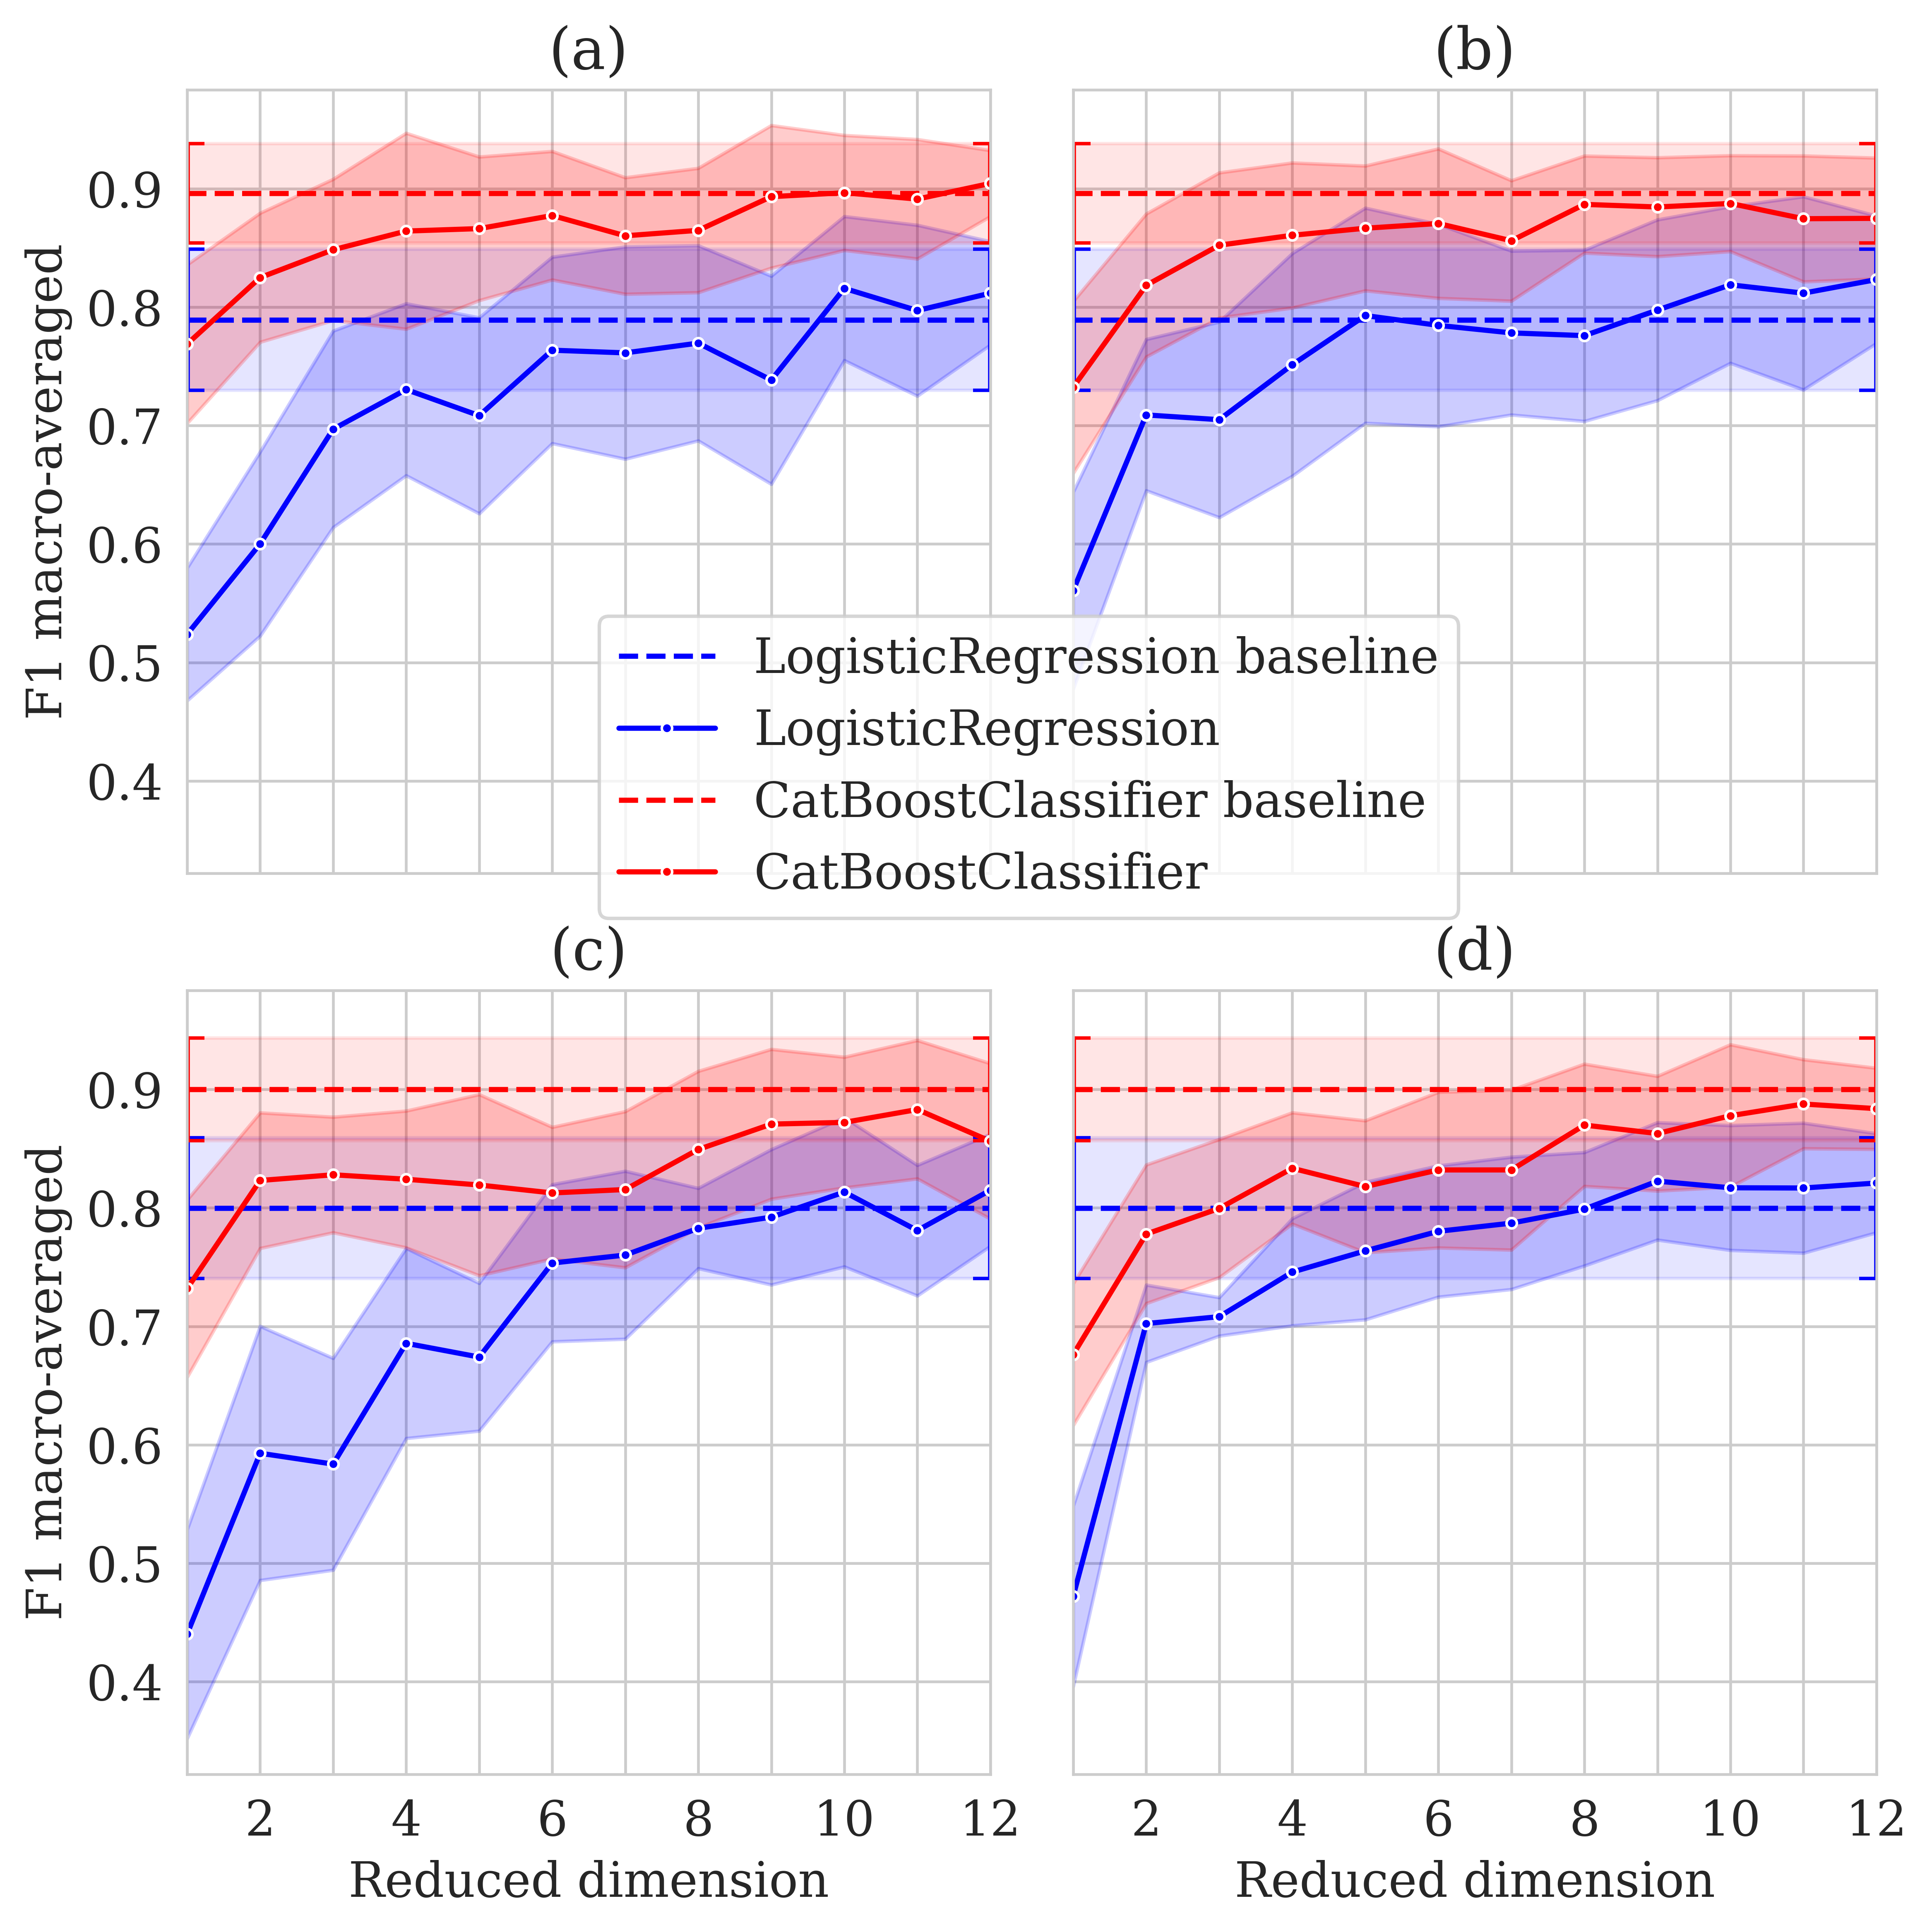

In [14]:
sns.set_style('whitegrid', {'font.family':'serif', 'font.serif':'Times New Roman'})
plt.rcParams.update({'font.size': 14})

metric = 'cv_test_f1_macro'
model_group = 'default'
SMOTE_opt = 'no'
smote_dict = {
    'splashing': 'SMOTE',
    'no_fragmentation': 'SMOTENC',
}
dim_reduction_methods = ('vae', 'pca')

colors = ['blue', 'red']

fig, axes = plt.subplots(
    2, 2, figsize=(8,8), dpi=600, sharex=True, sharey=True,
)

titles = 'abcd'
# Store lines for common legend
legend_lines = []
legend_labels = []

for i, target in enumerate(['splashing', 'no_fragmentation']):
    for j, dim_reduction_method in enumerate(dim_reduction_methods):
        for k, model_class in enumerate(['Logit', 'CatBoostClassifier']):
            
            df_plot = df_metrics[
                (df_metrics['target'] == target)
                & (df_metrics['model_class'] == model_class)
                & (df_metrics['dim_reduction_method'] == dim_reduction_method)
            ]
            
            df_plot = (
                df_plot
                .explode(metric)
                .reset_index(drop=True)
            )
            
            SMOTE = smote_dict[target]
            baseline_df = df_main_metrics[
                (df_main_metrics['target'] == target)
                & (df_main_metrics['model_class'] == model_class)
                & (df_main_metrics['model_group'] == model_group)
                & (df_main_metrics['SMOTE'] == SMOTE)
                & (df_main_metrics['SMOTE_opt'] == SMOTE_opt)
            ]
            
            metrics = baseline_df[metric].values[0]
            
            mean = np.mean(metrics)
            std = np.std(metrics)
            
            # Add baseline line
            line = axes[i, j].axhline(
                y=mean,
                color=colors[k],
                linestyle='--',
                label=f'{model_class} baseline',
            )
            
            # Add error bars at the edges
            axes[i, j].errorbar(
                x=[1, df_plot['reduced_dimension'].max()],  # edge points on x
                y=[mean, mean],  # y values
                yerr=[std, std],  # errors
                color=colors[k],
                fmt='none',  # only errors, no markers
                capsize=5,  # size of cross lines
            )
            
            axes[i, j].fill_between(
                x=[1, df_plot['reduced_dimension'].max()],
                y1=mean - std,
                y2=mean + std,
                color=colors[k],
                alpha=0.1,
            )
            
            # Add line with points
            line_points = sns.lineplot(
                data=df_plot,
                x='reduced_dimension',
                y=metric,
                # hue='dim_reduction_method',
                ax=axes[i, j],
                label=model_class,
                errorbar='sd',
                marker='.',
                color=colors[k],
                legend=False,  # Disable individual legends
            )
            
            # Store lines and labels for common legend only once
            if i == 0 and j == 0:
                legend_lines.extend([line, line_points.lines[-1]])
                legend_labels.extend([f'{model_class} baseline', model_class])
        
        # axes[i,j].legend(loc='lower right')
        axes[i,j].set_title(f'({titles[i*2+j]})')
        # axes[i,j].xaxis.set_major_locator(plt.MultipleLocator(2))
        axes[i,j].xaxis.set_major_locator(plt.MultipleLocator(2))
        axes[i,j].xaxis.set_minor_locator(plt.MultipleLocator(1))
        axes[i,j].set_xlim(1, 12)
        axes[i,j].grid(which='minor')
        axes[i,j].set_ylabel('F1 macro-averaged')
        axes[i,j].set_xlabel('Reduced dimension')


legend_labels = list(
    map(
        lambda label: label.replace('Logit', 'LogisticRegression'),
        legend_labels
    )
)

# Add common legend
fig.legend(
    legend_lines,
    legend_labels,
    loc='center right',  # Place legend on right center
    bbox_to_anchor=(0.76, 0.6),  # Legend position
)

# Adjust margins for legend placement
plt.tight_layout()
plt.savefig(
    Path('../results/dim_reduction_comparison.pdf'),
    dpi=600,
)